# FLOW SHOP SCHEDULING PROBLEM (FSSP)

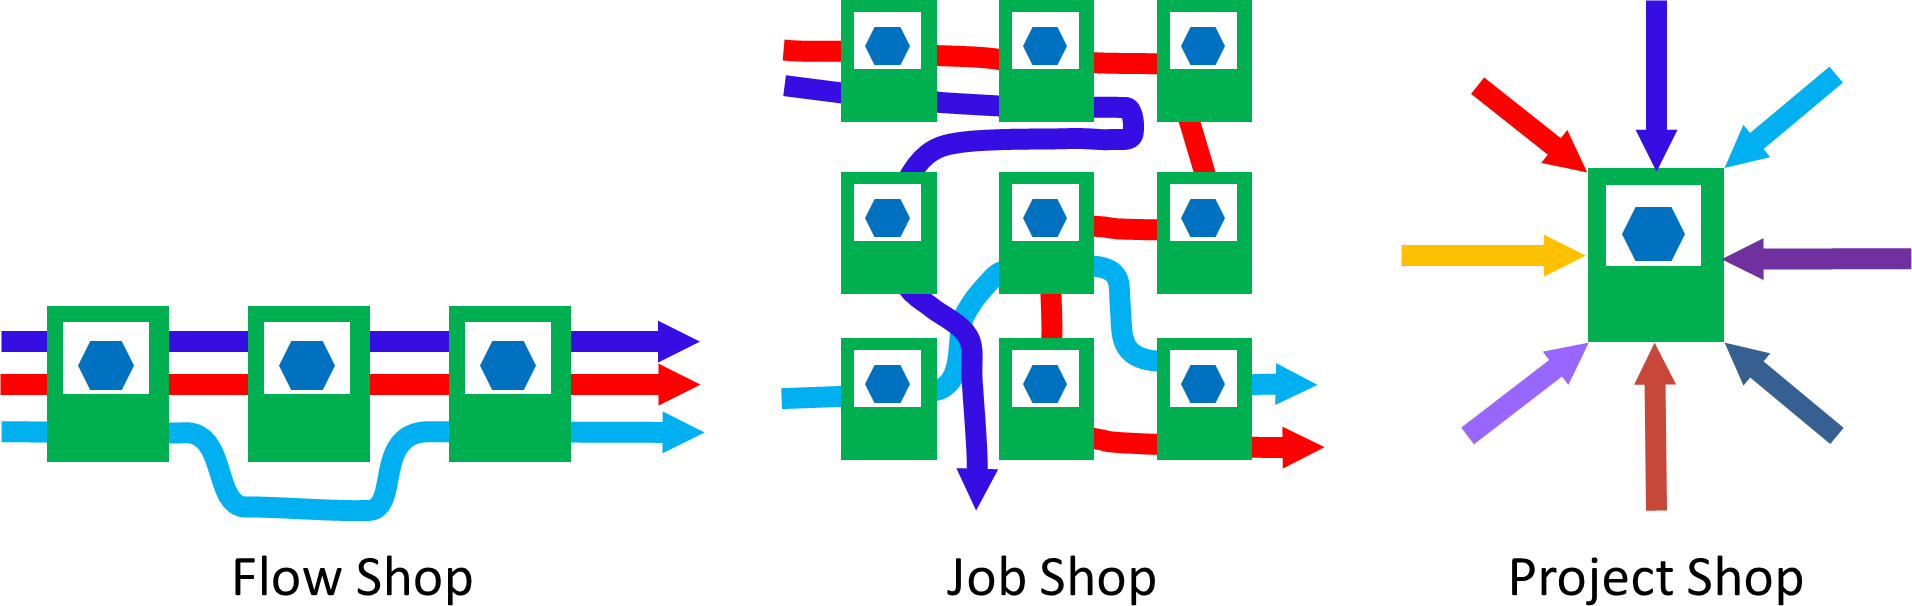

## Example

* a) Calculate the makespan of the problem
* b)  Calculate the idle time (inactivity) of M1 and M2
* c) Create a Gant Chart of the problem
* d) Inverse the sequence order
* e) Calculate the new makespan (inversed sequence)
* f) Calculate the new idle time of M1 and M2 (inversed sequence)
* g) Create an algorithm to obtain an optimal sequence order (Johnson's rules)

The first part of the code is already defined, you may continue the code or create a new one

## Documentation for creating Gantt chart
https://plotly.github.io/plotly.py-docs/generated/plotly.figure_factory.create_gantt.html

https://plotly.com/python/gantt/


In [ ]:
import pandas as pd
import plotly.figure_factory as ff
#import plotly.express as px

#Example of DataFrame and how to access a value
df = pd.DataFrame([
    dict(Task="Job A", Start='2009-01-01', Finish='2009-02-28'),
    dict(Task="Job B", Start='2009-03-05', Finish='2009-04-15'),
    dict(Task="Job C", Start='2009-02-20', Finish='2009-05-30')
])
print(df)
print(df["Finish"][2])

# Create Gantt chart

dataGantt =  pd.DataFrame([
    dict(Job="J1", Task = "M1", Start = 0, Finish = 3),
    dict(Job="J2", Task = "M1", Start = 3, Finish=7),
    dict(Job="J3", Task = "M1", Start = 7, Finish = 17),
    dict(Job="J4", Task = "M1", Start = 17, Finish = 25),
    dict(Job="J5", Task = "M1", Start = 25, Finish = 40),
    dict(Job="J1", Task = "M2", Start = 3, Finish = 8),
    dict(Job="J2", Task = "M2", Start = 7, Finish = 20),
    dict(Job="J3", Task = "M2", Start = 20, Finish = 23),
    dict(Job="J4", Task = "M2", Start = 25, Finish = 35),
    dict(Job="J5", Task = "M2", Start = 40, Finish = 48)
    ])
# pdDataFrame mandatory keywords: "Task", "Start", "Finish"

# Dictionary of colors according to the Job
colors = {'J1': 'rgb(255, 0, 0)', #red
          'J2': 'rgb(0, 0, 255)', #blue
          'J3': 'rgb(76, 153, 0)', #green
          'J4': 'rgb(255, 255, 0)',#yellow
          'J5': 'rgb(255, 128, 0)' #orange
          }

fig = ff.create_gantt(dataGantt, title = "Flow shop (example)", colors=colors, index_col='Job',  bar_width = 0.4, show_colorbar=True, group_tasks=True)
fig.update_layout(xaxis_type='linear', autosize=False, width=800, height=400)
fig.show()


    Task       Start      Finish
0  Job A  2009-01-01  2009-02-28
1  Job B  2009-03-05  2009-04-15
2  Job C  2009-02-20  2009-05-30
2009-05-30


In [ ]:
# Calcular makespan
# jobs = {1, .... j}
# maquinas = {1, .... i}

# Para cada job "j"
  # Para cada maquina "i"
    # si primer job j=1 y primera maquina i=1
      #lastJob = job "j"
      # inicio
      # startDate = 0
    # sino
      # si otro job
        # si primera maquina i = 1
          # startDate = fin job j-1 en maquina i=1
        # sino
          # startDate = max(fin job j-1 en maquina actual, fin job j en maquina i-1)
      # sino (job j =1 y maquina i =/= 1)
          # startDate = endDate de job j en maquina i-1
    # Duracion job "j" maquina "i"
    # pj = (encontrar la duracion)

    # Fin job j
    # endDate = startDate + pj

    # si job en ultima maquina
      # fin ejecucion job
      # cj = endDate
      # Actualizar lista de cj
    # lastjob = job "j"


In [127]:
import pandas as pd
import plotly.figure_factory as ff
import random

# Datos

#--------- Test 1 --------
vlstMachines = ["M1", "M2"]
vlstJobs = ["J1", "J2", "J3", "J4", "J5"]
vlstDurations = [(3,4), (7,3), (8,10), (4,5), (6,7)]
vlstSequence = ["J1", "J4", "J5", "J3", "J2"]
#--------------------------
'''
#--------- Test 2 --------
vlstMachines = ["MA", "MB"]
vlstJobs = ["J1", "J2", "J3", "J4", "J5"]
vlstDurations = [(14,5), (6,10), (23,4), (10,15), (5,8)]
vlstSequence = ["J5", "J2", "J4", "J1", "J3"]
#--------------------------
'''
'''
#--------- Test 3 --------
vlstMachines = ["MA", "MB", "MC"]
vlstJobs = ["J1", "J2", "J3", "J4", "J5", "J6"]
vlstDurations = [(3, 8, 13), (12, 6, 14), (5, 4, 9), (2, 6, 12), (9, 3, 8), (11, 1, 13)]
vlstSequence = ["J4", "J3", "J1", "J6", "J2", "J5"]
#--------------------------
'''

vlstCj = []
dataGantt = []

# Crear Gantt con todos los jobs, inicios y fin en cero
for i in vlstSequence:
  for j in vlstMachines:
    dataGantt.append(dict(Job = i, Task = j, Start = 0, Finish = 0))
dataGantt = pd.DataFrame(dataGantt) # convierte datatype de list a dataframe

def miGetRow(pDataFrame, psJob, psMachine):
  '''Get number of row given a dataframe, job name and machine name'''
  for iRow in range(pDataFrame.shape[0]):
    if pDataFrame.iloc[iRow,0] == psJob and pDataFrame.iloc[iRow,1] == psMachine:
      return iRow

def random_color_generator():
    r = random.randint(0, 255)
    g = random.randint(0, 255)
    b = random.randint(0, 255)
    return (r, g, b)

# Calcular makespan
# jobs = {1, .... j}
# maquinas = {1, .... i}

# Para cada job "j"
for j in range(len(vlstSequence)):
  vsCurrentJob = vlstSequence[j]
  # Para cada maquina "i"
  for i in range(len(vlstMachines)):
    vsCurrentMachine = vlstMachines[i]
    # si primer job j=1 y primera maquina i=1
    if j == 0 and i == 0:
      #lastJob = job "j"
      vsLastJob = vsCurrentJob
      # inicio
      viStartDate = 0
    # sino
    else:
      # si otro job
      if j != 0:
        # si primera maquina i = 1
        if i == 0:
          # startDate = fin job j-1 en maquina i=1
          vsPreviousJob = vlstSequence[j-1]
          iRow = miGetRow(dataGantt, vsPreviousJob, vsCurrentMachine)
          viStartDate = dataGantt.iloc[iRow, 3]

        # sino
        else:
          # startDate = max(fin job j-1 en maquina actual, fin job j en maquina i-1)
          vsPreviousJob = vlstSequence[j-1]
          vsPreviousMachine = vlstMachines[i-1]

          iRow = miGetRow(dataGantt, vsPreviousJob, vsCurrentMachine)
          viEndDatePreviousJobCurrentMachine = dataGantt.iloc[iRow, 3]
          iRow = miGetRow(dataGantt, vsCurrentJob, vsPreviousMachine)
          viEndDatePreviousJob = dataGantt.iloc[iRow, 3]
          viStartDate = max(viEndDatePreviousJobCurrentMachine, viEndDatePreviousJob)
          if vsCurrentJob == "J6" and vsCurrentMachine == "MC":
            print("J6-MC", viStartDate)

      # sino (job j =1 y maquina i =/= 1)
      else:
          # startDate = endDate de job j en maquina i-1
          vsPreviousMachine = vlstMachines[i-1]
          iRow = miGetRow(dataGantt, vsCurrentJob, vsPreviousMachine)
          viEndDatePreviousJob = dataGantt.iloc[iRow, 3]
          viStartDate = viEndDatePreviousJob

    # Duracion job "j" maquina "i"
    viJobIndex = vlstJobs.index(vsCurrentJob)
    viMachineIndex = vlstMachines.index(vsCurrentMachine)
    pj = vlstDurations[viJobIndex][viMachineIndex]
    if vsCurrentJob == "J6" and vsCurrentMachine == "MC":
      print("jobindex", viJobIndex)
      print("machineindex", viMachineIndex)
      print("J6-MC", pj)

    # Fin job j
    # endDate = startDate + pj
    viEndDate = viStartDate + pj


    # si job en ultima maquina
    if i == len(vlstMachines)-1:
      # fin ejecucion job
      cj = viEndDate
      # Actualizar lista de cj
      vlstCj.append(cj)
    # lastjob = job "j"
    vsLastJob = vsCurrentJob

    # actualizar dataframe
    viRowDataFrame = miGetRow(dataGantt, vsCurrentJob, vsCurrentMachine)
    dataGantt.iloc[viRowDataFrame,2] = viStartDate
    dataGantt.iloc[viRowDataFrame,3] = viEndDate


# Output
print(dataGantt)
viMakespan = vlstCj[-1]
print("Makespan: ", viMakespan)

# tiempo inactividad
vlstInactividad = []
vlstProductividad = []
for i in range(len(vlstMachines)):
  iProdMachine = 0
  for j in range(len(vlstDurations)):
    iProdMachine += vlstDurations[j][i]
    if j == len(vlstDurations)-1:
      vlstProductividad.append(iProdMachine)

for i in range(len(vlstMachines)):
  vlstInactividad.append((viMakespan - vlstProductividad[i])/viMakespan)


for i in range(len(vlstMachines)):
  str(vlstInactividad[i])
  print(f"Inactividad de {vlstMachines[i]}: {vlstInactividad[i]:.2%}")

# Generar colores aleatorios para la cantidad de jobs "j"
colors = {}
#random.seed(42)
for i in vlstJobs:
  random_color = random_color_generator()
  colors [i] = 'rgb'+str(random_color)

fig = ff.create_gantt(dataGantt, title = "Flow shop (example)", colors=colors, index_col='Job',  bar_width = 0.4, show_colorbar=True, group_tasks=True)
fig.update_layout(xaxis_type='linear', autosize=False, width=800, height=400)
fig.show()


  Job Task  Start  Finish
0  J1   M1      0       3
1  J1   M2      3       7
2  J4   M1      3       7
3  J4   M2      7      12
4  J5   M1      7      13
5  J5   M2     13      20
6  J3   M1     13      21
7  J3   M2     21      31
8  J2   M1     21      28
9  J2   M2     31      34
Makespan:  34
Inactividad de M1: 17.65%
Inactividad de M2: 14.71%


## Integrantes

In [ ]:
# Nombres y apellidos
# 1.
# 2.
# 3.
# 4.

## Ejercicios
Con los mismos datos del ejemplo ("Test 1"),
calcular el makespan, el tiempo ocioso de cada máquina para cada una de las siguientes secuencias:

1. Secuencia ["J1", "J2", "J3", "J4", "J5"]
2. Secuencia ["J2", "J1", "J3", "J4", "J5"]
3. Secuencia ["J1", "J3", "J2", "J4", "J5"]
4. Secuencia ["J1", "J2", "J4", "J3", "J5"]
5. Secuencia ["J1", "J2", "J3", "J5", "J4"]
6. Secuencia ["J5", "J4", "J3", "J2", "J1"]

* ¿Cuál de las 6 secuencias tiene menor makespan?
* ¿Cuantas combinaciones se pueden probar para encontrar el mínimo valor de makespan para el problema propuesto?

In [ ]:
# 1 Secuencia ["J1", "J2", "J3", "J4", "J5"]

In [ ]:
# 2 Secuencia ["J2", "J1", "J3", "J4", "J5"]

In [ ]:
# 3 Secuencia ["J1", "J3", "J2", "J4", "J5"]

In [ ]:
# 4 Secuencia ["J1", "J2", "J4", "J3", "J5"]

In [ ]:
# 5 Secuencia ["J1", "J2", "J3", "J5", "J4"]

In [ ]:
# 6 Secuencia ["J5", "J4", "J3", "J2", "J1"]